<a href="https://colab.research.google.com/github/haze25102583/CNN/blob/main/day3_lesson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SECTION 01.** 기준 CNN의 성능 확인 **&** 과적합

### 검증 데이터의 신호를 읽고, 한 번에 한 요소만 실험.

1. 훈련 정확도는 높으나 검증 성능이 멈출 때
2. 데이터를 더 모으기 어려울 때
3. 숨은 클래스별 오류를 찾을 때
4. 사전 학습 모델의 사용여부, 사전학습 층의 동결범위

### 개선 전략
1. 데이터 증강의 적용 여부/ 강도
2. Dropout, L2, BatchNorm

In [ ]:
import numpy as np

# 1. 전체 데이터 번호
idx = np.arange(20)

# 2. 역할별 분리
train = idx[:14]
validation = idx[14:17]
test = idx[17:]

# 3. 크기, 내용, 겹침 check
print("split: ", train, validation, test)
print("count: ", len(train), len(validation), len(test))
assert len(train) + len(validation) + len(test) == len(idx)

assert set(train).isdisjoint(validation)                            # set() : 중복을 허용하지 x 순서가 없는 Set 자료형
assert set(train).isdisjoint(test)
assert set(validation).isdisjoint(test)

assert np.array_equal(np.r_[train, validation, test], idx)          # np.r_ >> array들을 세로/가로 방향으로 이어 붙임
print("분리 확인 완료")

split:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13] [14 15 16] [17 18 19]
count:  14 3 3
분리 확인 완료


In [ ]:
models = {
    "A":(0.98, 0.86),
    "B":(0.92, 0.89),
    "C":(0.60, 0.59),
}

# 1. 검증 정확도와 일반화 간격 계산
result =  {}
for name, (train_acc, val_acc) in models.items():
  gap = train_acc - val_acc
  result[name] = {"val":val_acc, "gap":gap}
  print(name, "val=", val_acc, "gap= ", round(gap, 2))

# 2. 서로 다른 기준으로 모델 찾기
best_val = max(result, key=lambda k:result[k]["val"])           # lambda : 익명함수, k:매개변수
largest_gap = max(result, key=lambda k:result[k]["gap"])

assert best_val == "B"
assert largest_gap == "A"
assert result["C"]["val"] < 0.60
print("best: ", best_val, "/ largest gap: ", largest_gap)

A val= 0.86 gap=  0.12
B val= 0.89 gap=  0.03
C val= 0.59 gap=  0.01
best:  B / largest gap:  A


1. train
```
가중치를 직접 학습
```

2. validation
```
학습중간에 성능 점검. 최적 모델 선택
```

3. test
```
모든 선택 끝내고 최종 성능 evaluate
```

### 정확도 곡선의 4가지 패턴
1. 함께 개선
```
Train▲,  Validaion▲
간격▼
```

2. 과적합
```
Train ▲,  Validaion▼
검증 최고점 이후 간격▲
```

3. 과소적합
모델이 패턴을 아직 제대로 학습 x

4. 불안정
```
validation 정확도가 요동침
-> 학습률, 데이터 수, 분할 review
```


In [ ]:
# epoch별 훈련, 검증 정확도
train_acc = [0.64, 0.74, 0.82, 0.89, 0.94]            # train_acc : 계속 상승
val_acc = [0.63, 0.72, 0.77, 0.76, 0.74]              # val_acc : 상승 -> 감소 (overfit)

gaps = []

# epoch 별 훈련-검증 정확도 차이 계산
for epoch, (train, val) in enumerate(zip(train_acc, val_acc), start=1):     # 여러 개의 순회 가능한(iterable) 객체를 받아 동일한 인덱스의 요소끼리 튜플로 묶어주는 내장 함수
                                                                            # zip([1, 2], ['a', 'b']) >>> (1, 'a'), (2, 'b')
  gap = train - val
  gaps.append(gap)

  print(
      f"epoch {epoch}: "
      f"train = {train:.2f}, "
      f"val={val:.2f}, "
      f"gap={gap:.2f}"
  )

  # 처음과 마지막 epoch 차이 비교
  print("처음 차이: ", round(gaps[0], 2))
  print("마지막 차이: ", round(gaps[-1], 2))
  print("차이가 커졌는가?", gaps[-1]>gaps[0])

epoch 1: train = 0.64, val=0.63, gap=0.01
처음 차이:  0.01
마지막 차이:  0.01
차이가 커졌는가? False
epoch 2: train = 0.74, val=0.72, gap=0.02
처음 차이:  0.01
마지막 차이:  0.02
차이가 커졌는가? True
epoch 3: train = 0.82, val=0.77, gap=0.05
처음 차이:  0.01
마지막 차이:  0.05
차이가 커졌는가? True
epoch 4: train = 0.89, val=0.76, gap=0.13
처음 차이:  0.01
마지막 차이:  0.13
차이가 커졌는가? True
epoch 5: train = 0.94, val=0.74, gap=0.20
처음 차이:  0.01
마지막 차이:  0.2
차이가 커졌는가? True


### 과적합
최고 validation 성능 이후에도 학습을 오래 계속

1. EarlyStopping
```
최고 검증 시점을 저장
```
2. 데이터 증강 ->> 입력의 다양성
3. 규제 강도 시험
```
Dropout, L2
```

### 기준 모델을 확정하기 전 확인
1. train, validation test 분할. seed 고정
2. 출력층, loss, label 형식 일치
3. validation 성능이 가장 좋았던 가중치 ->> 저장
4. 입력 데이터의 shape, dtype, 값 범위
5. history에 train, validation의 loss 와 accuracy 기록
6. 모든 선택이 끝난 후 test 데이터 사용

### 기준 모델을 통해 개선 실험의 결과를 판단


# **SECTION 2.** 데이터 증강 -> 입력의 다양성

데이터 증강은 **성능 개선**, **라벨 유지** 모두 고려

### 레이어
처음에는 약한 강도로 시작

1. **RandomFlip** : 좌우 방향이 의미 x
2. **RandomRotation** :  작은 촬영 기울기
3. **RandomZoom** : 거리 변화, 여백
4. **RandomContrast** : 조명 변화


Keras의 Random* 증강 레이어는 training=True 일 때만 변형

label:  9
shape:  (28, 28, 1) (28, 28, 1)
range:  0.0 0.9926837682723999


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


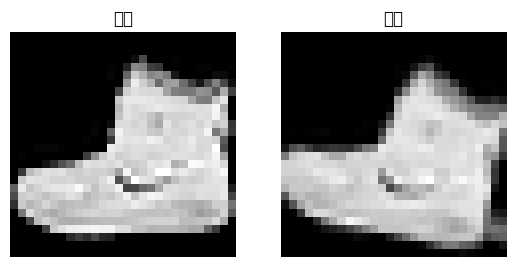

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
(x, y), _ = tf.keras.datasets.fashion_mnist.load_data()

# 1. 첫 이미지를 0~1, (H, W, C)로 준비
image = x[0].astype("float32")/255.
image = image[..., None]                                    #

# 2. 약한 회전 적용
rotate = tf.keras.layers.RandomRotation(
               0.08, fill_mode="nearest", seed=42)                        # tf.keras.layers.RandomRotation(fill_mode="nearst")
aug = rotate(image[None], training=True)[0]                               # augment : 데이터 증강
print("label: ", int(y[0]))
print("shape: ", image.shape, aug.shape)
print("range: ", float(tf.reduce_min(aug)),                               # tf.reduce_* : tensor의 차원을 줄임
      float(tf.reduce_max(aug)))

# 3. 원본과 증강 결과비교
for i, (img, title) in enumerate([(image, "원본"), (aug, "회전")]):       # i=0 이면) img=image, title="원본"
                                                                          # i=1 이면) img=arg,   title="회전"
    plt.subplot(1, 2, i+1)
    plt.imshow(img[..., 0], cmap="gray")                                  # imshow() : 2차원 배열 / 이미지 파일 -> 이미지 형태
    plt.title(title); plt.axis("off")

plt.show()

assert image.shape == aug.shape
assert 0. <= float(tf.reduce_min(aug)) <= float(tf.reduce_max(aug)) <= 1.

### 데이터 증강
1. 증강 : train -> o                validation -> x                test -> x
2. 약한 변형 하나부터 순서대로
3. min, max, shape 출력하고 이미지 표시
4. seed, epoch, batch, 평가 방법 -> 유지

# **SECTION 3.** 일반화 도구 ->> 과적합 완화, 학습 안정화

권장 순서 :  기준 모델 ->> Dropout ->> BatchNorm ->> 필요할 때 함께 적용



### Dropout

뉴런을 삭제x.


1. 핵심 목적

    특정 특징 의존 감소

2. 훈련 중

    일부 출력 무작위로 0
3. 추론 중
    
    끄지 않음


5. 주의점


    rate 크면 과소적합

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
tf.random.set_seed(42)
x = tf.ones((1, 8))                              # (1,8)을 모두 1로 fill
drop = layers.Dropout(0.5)

# 1. 같은 입력으로 훈련 호출 두번
train_a = drop(x, training=True)
train_b = drop(x, training=True)

# 2. 추론 호출
infer = drop(x, training=False)
print("train A: ", train_a.numpy())             # train A:  [[0. 0. 0. 0. 2. 0. 0. 2.]]
print("train B: ", train_b.numpy())             # train B:  [[0. 2. 0. 0. 2. 0. 0. 0.]]
print("inter  : ", infer.numpy())               # inter :  [[1. 1. 1. 1. 1. 1. 1. 1.]]

# 3. 동작 불변 조건 확인
assert tf.reduce_any(train_a == 0.)
assert tf.reduce_any(train_b == 0.)
assert not tf.reduce_all(train_a == train_b)

tf.debugging.assert_equal(infer, x)
print("훈련은 무작위, 추론은 원본 유지")

train A:  [[2. 0. 0. 2. 2. 0. 0. 0.]]
train B:  [[2. 0. 0. 2. 0. 2. 2. 2.]]
inter  :  [[1. 1. 1. 1. 1. 1. 1. 1.]]
훈련은 무작위, 추론은 원본 유지


### BatchNorm
shape을 바꾸지 x. 다음 층이 학습하기 쉬운 값 범위를 만듦.

1. 핵심 목적

    층 사이 활성값의 범위, 학습 흐름 ->> 안정화

2. 훈련 중

    배치 평균, 분산 사용
    현재 배치, 이동 통계 갱신

3. 추론 중

    저장된 이동 평균, 분산 사용


4. 학습 파라미터

    weight, bias, 비학습 이동 통계

5. 작은 배치, 전이학습시 주의

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

x = tf.constant([                                                                 # tf.constant() : 상수 텐서
    [10., 12.], [20., 24.],
    [30., 36.], [40., 48.],
])

# 1. 학습 모드 : 현재 배치 통계 사용
bn = layers.BatchNormalization(center=False, scale=False)                         # center= bias, scale= weight
                                                                                  # 하나의 레이어에서 center, scale을 고정시킴. 이후 다음 레이어에서는 정상적으로 갱신
y = bn(x, training=True)

# 2. 특징축별 통계 확인
mean = tf.reduce_mean(y, axis=0)
std = tf.math.reduce_std(y, axis=0)

print("input shape: ", x.shape)                                                   # input shape:  (4, 2)
print("output shape: ", y.shape)                                                  # output shape:  (4, 2)
print("mean: ", mean.numpy())                                                     # mean:  [ 2.9802322e-08 -1.1920929e-07]
print("std: ", std.numpy())                                                       # std:  [0.999996  0.9999972]


assert x.shape == y.shape
np.testing.assert_allclose(mean, [0., 0.], atol=.01)                              # atol = absoulte tolerance : 절대 오차 허용값
np.testing.assert_allclose(std, [1., 1.], atol=.01)

input shape:  (4, 2)
output shape:  (4, 2)
mean:  [ 2.9802322e-08 -1.1920929e-07]
std:  [0.999996  0.9999972]


### EarlyStopping

마지막 모델x

검증 손실이 가장 좋았던 모델

In [ ]:
import numpy as np
from tensorflow import keras

val_loss = np.array([.62, .51, .45, .46, .47, .48])

# 1. 콜백의 세 핵심 설정
stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

#2. 곡선에서 최적 epoch 찾기
best_epoch = int(val_loss.argmin() + 1)
waited = len(val_loss) - best_epoch
print("monitor: ", stop.monitor)
print("patience: ", stop.patience)
print("restore: ", stop.restore_best_weights)
print("best epoch: ", best_epoch, "/ waited: ", waited)

assert stop.monitor == "val_loss"
assert stop.patience == 3
assert stop.restore_best_weights is True
assert best_epoch == 3 and waited == 3


monitor:  val_loss
patience:  3
restore:  True
best epoch:  3 / waited:  3


### L2

1. 목적

      train 성능은 높고, validation 성능은 낮을 때

      한 특징에만 의존x, 큰 가중치를 눌름

2. 특징

      (전체 손실) = (분류 손실) + (가중치 제곱의 합)

      -> 큰 가중치이면 더 큰 벌점
      




```
layers.Dense(128, activation="relu",
              kernel_regularizer= keras.regularizes.l2(1e-4)

# kernel_regularizer : 가중치에 규칙 추가
# l2 : 큰 가중치에 제곱 비용
# 1e-4 :  규제 강도 -> 작게 시작 (=0.0001)
```




In [ ]:
import numpy as np
w = np.array([0.2, 1.0, 3.0])
l2_rate = 1e-3

# 1. 가중치별 제곱과 벌점 기여도
squared = w ** 2
contribution = l2_rate * squared
penalty = contribution.sum()
share = contribution / penalty

for value, sq, part in zip(w, squared, contribution):               # zip() : 여러 개의 순회 가능한(iterable) 객체를 동일한 인덱스의 요소끼리 튜플로 묶어주는 내장 함수
  print(f"w={value:.1f}  w²={sq:.2f}  penalty={part:.4f}")

# 2. 가장 큰 가중치의 기여 비율
largest_share = share.argmax()
print("total: ", round(penalty, 5))
print("largest index: ", largest_share)
print("largest share: ", round(share[largest_share], 3))

assert np.isclose(penalty, 0.01004)
assert largest_share == 2
assert share[2] > 0.89

print("큰 가중치가 벌점의 대부분을 차지")


### 일반화 도구
1. 기준

    장치 없는 모델

2. 증강

    입력 다양성 효과 check

3. Dropout

    의존성 감소 효과 확인

4. BatchNorm

    학습 안정성 확인

5. EarlyStop

    중단 시점 효과 check

# **SECTION 4.** 혼동행렬로 오류의 구조 읽기

클래스별 recall, 혼동행렬 ->> 개선 대상 확인

### 혼동행렬

**행** : 실제 클래스

**열** : 예측 클래스


    -> 몇 개 틀렸는 지
    -> 어느 방향으로 틀렸는 지

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = [0, 0, 0, 1, 1, 1, 2, 2]
y_pred = [0, 1, 0, 1, 2, 1, 2, 0]
labels = [0, 1, 2]

# 1. 행 = 실제, 열 = 예측
cm = confusion_matrix(y_true, y_pred, labels=labels)
print(cm)

# 2. 대각선 정답, 바깥 오류
correct = int(np.trace(cm))                                                      # trace() : 2차원 행렬의 대각합
errors = int(cm.sum()-correct)

expected = np.array([
    [2, 1, 0],
    [0, 2, 1],
    [1, 0, 1]
])

print("correct: ", correct, "/ errors: ", errors)
np.testing.assert_array_equal(cm, expected)

assert correct==5 and errors==3
assert cm[0, 1]==1 and cm[2, 0]==1

[[2 1 0]
 [0 2 1]
 [1 0 1]]
correct:  5 / errors:  3


### Precision은 오탐, Recall은 놓침

1. ** 참양성** : 실제 셔츠를 정확히 찾음 ->> **TP**
2. **거짓 음성** : 실제 셔츠를 놓침 ->> **FN**
3. **거짓 양성** : 셔츠 아닌데 셔츠라고 알림 ->> **FP**
4. **참음성** : 셔츠 아님을 정확히 구분 ->> **TN**

### Precision
정밀도 : 모델의 예측을 얼마나 믿을 수 있는가  (잘못 알람x)

Precision = TP/(TP + FP)

### Recall
재현율 : 실제를 얼마나 놓치지 않고 찾았는가

Recall = TP/(TP + FN)


In [ ]:
import numpy as np
tp, fp, fn = 8, 2, 4

# 1. 기본 지표
precision = tp / (tp + fp)
recall = tp / (tp + fn)

# 2. fp, fn 각각 늘려 비교
precision_more_fp = tp / (tp + fp + 2)
recall_more_fn = tp / (tp + fn + 2)

print("precision: ", round(precision, 3))
print("recall   : ", round(recall, 3))

print("FP+2 precision : ", round(precision_more_fp, 3))
print("FN+2 recall    : ", round(recall_more_fn, 3))

assert np.isclose(precision, 0.8)
assert np.isclose(recall, 2/3)
assert precision_more_fp < precision
assert recall_more_fn < recall

print("FP↑ → precision↓")
print("FN↑ → recall↓")

In [2]:
import numpy as np

y_prob = np.array([
    [0.1, 0.7, 0.2],
    [0.6, 0.2, 0.2],
])

# 1. 확률 합과 예측 클래스
row_sums = y_prob.sum(axis=1)                                 # 각 행의 확률 합이 1
y_pred = y_prob.argmax(axis=1)
confidence = y_prob.max(axis=1)

print("shape: ", y_prob.shape)
print("row sums: ", row_sums)
print("class: ", y_pred)
print("confidence: ", confidence)

# 2. 출력 불변조건 확인
assert y_prob.shape == (2, 3)

np.testing.assert_allclose(row_sums, [1., 1.])
np.testing.assert_array_equal(y_pred, [1, 0])
np.testing.assert_allclose(confidence, [0.7, 0.6])

print("확률 -> 클래스 번호 변환 완료")

shape:  (2, 3)
row sums:  [1. 1.]
class:  [1 0]
confidence:  [0.7 0.6]
확률 -> 클래스 번호 변환 완료


### 오류 원인

이미지를 함께 보고 원인을 추정

1. DATA

    라벨 오류, 표본 부족과 불균형, 배경과 촬영 편향

2. MODEL

    표현력 부족, 과적합과 과소적합, 입력 해상도 손실

3. EVALUATION

    분할 누수, 클래스 순서 오류, 부적절한 지표

### 오류 수정

    위치 변화 : 이동 증강
    
    훈련과 검증의 큰 간격 : 증강, Dropout, EarlyStopping

    유사 클래스 간 혼동 : 해상도, 특징 추출기, 데이터 => 확인

    소수 클래스의 낮은 recall : 분할, 표본 수, class weight => 점검

    낮은 성능 : 학습률, 모델 용량, 전처리 => 재검토

# 5. 사전학습 모델

### 전이 학습
이미 배운 모델 ~> 지식을 가져와 새 문제에 적용 (= 새로운 데이터의 적합성 test)
작은 데이터에서 과적합 위험을 방지
새로운 데이터의 적합성을 시험
1. 불러오기
2. 원래 분류기 제거
3. 동결
4. 새 분류기 추가
5. 미세 조정


### 특징 추출기 재사용
1. 사전학습 모델
2. 특징 추출기 동결
: 기존 특징을 잃지 않도록 처음에는 학습 x
3. 작은 새 데이터 ~> 새 분류기 학습 ~> 이것만 가중치 갱신
4. 새 문제: 특징 추출 ~> 예측

### 미세 조정 (Fine-tuning)
새 분류기가 안정 -> 상위 일부 층만 열고, 낮은 학습률로 조금 더 조정

### 사전 학습 모델

1. **VGG16** : 단순한 구조, 큰 파라미터
2. **ResNet50** : 잔차연결로 깊은 학습
3. **EfficientNet80** : 깊이, 너비, 해상도를 균형 있게 확장
4. **MobileNetV2** : 가볍고 빠른 특징 추출기

In [8]:
# 입력 전처리 code

def prepare_image(x, y):
  x = tf.image.resize(x, (96, 96))                          # tf.image.resize(image, size) : image를 원하는 size로 조절한다
  x = tf.image.grayscale_to_rgb(x)
  x = keras.application.mobilenet_v2.preprocess_input(x)    # preprocess_input() : 픽셀 범위 변환
  return x, y

In [9]:
# 사전학습 특징 추출기 불러오기
import tensorflow

base_model = tensorflow.keras.applications.MobileNetV2(
    input_shape = (96, 96, 3),
    include_top = False,                       # 특징 추출기는 동결 ~> 가중치 삭제x, 학습 중 업데이트 차단
    weights = "imagenet",                      # imagenet ~> 대규모 이미지 데이터 셋
)

base_model.trainable = False

In [13]:
# 새 분류기 연결 코드
import tensorflow.keras as keras

inputs = keras.Input((96, 96, 3))
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)                # 특징맵 ~> 벡터
x = keras.layers.Dropout(0.2)(x)                            # 과적합 완화
outputs = keras.layers.Dense(10, activation="softmax")(x)   # 클래스:10개, 확률
model = keras.Model(inputs, outputs)

In [15]:
# 미세 조정
base_model.trainable = True

for layer in base_model.layers[:-20]:               # [:-20]만 학습
  layer.trainable = False                           # base_model 동결
                                                    # 새 Dense 분류기가 안정될 때까지 학습

                                                    # 선택적인 fine tuning
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),         # 작은 학습률
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
)